# V4: Test sensitivity without claiming causality

## Goal
The direction of all three PPG changes survives the displayed reweightings and one-match omission checks. Anyang still conceded about 0.65 more goals per match when R24 is excluded (14 After vs 15 Before).

## Setup
Run the notebooks in v1 -> v2 -> v3 -> v4 order. Use a Python environment installed from `requirements.txt`.
The same editable code is in `scripts/v4_robustness.py`. No cell crawls a website.

## Context and assumptions
Saved official K League snapshot, audited on 2026-09-30. Before = R1-15; After = R16-30.
Gangwon-Incheon, assigned R22 and played on 2026-09-27, is included once after the break.
Raw CSVs must be supplied locally; see `data/README.md`. Outputs are written to the project, not the Desktop.
Club selection is post-hoc. No causal, weather, rest, xG, or predictive model is fitted.

## Steps


In [1]:
%matplotlib inline

### Setup: resolve paths without a personal Desktop location

In [2]:
from pathlib import Path
import sys

# Scripts resolve from their file; notebooks resolve from their working directory.
start = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
ROOT = next((p for p in (start, *start.parents) if (p / "project_config.py").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Open this notebook from inside the project folder.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from project_config import DATA_DIR, OUTPUT_DIR, TEAM_NAMES, FOCUS_TEAMS, COLORS, save_chart
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

STAGE = "v4"
from pathlib import Path
from statistics import mean, median
from collections import Counter
import csv
import json
import hashlib
import shutil

T = OUTPUT_DIR / STAGE
T.mkdir(parents=True, exist_ok=True)
SOURCE = OUTPUT_DIR / 'v1/01_team_match_dataset.csv'
FOCUS = ['Anyang', 'Daejeon', 'Jeju']
METRICS = ['goals_for', 'goals_against', 'shots', 'shots_on_target',
           'opponent_shots', 'opponent_shots_on_target', 'pass_attempts', 'points']
with SOURCE.open(encoding='utf-8-sig', newline='') as stream:
    rows = list(csv.DictReader(stream))
for row in rows:
    for field in ['round', 'game_id'] + METRICS:
        row[field] = int(row[field])
    row['result'] = 'W' if row['goals_for'] > row['goals_against'] else 'D' if row['goals_for'] == row['goals_against'] else 'L'
assert len(rows) == 360 and len({(r['team'], r['game_id']) for r in rows}) == 360
assert all(r['period'] == ('Before' if r['round'] <= 15 else 'After') for r in rows)
assert all(r['points'] == {'W': 3, 'D': 1, 'L': 0}[r['result']] for r in rows)
matches = [r for r in rows if r['team'] in FOCUS]
assert len(matches) == 90

def subset(team, period):
    return sorted([r for r in matches if r['team'] == team and r['period'] == period], key=lambda r: r['round'])

def save_csv(name, data):
    with (T / name).open('w', encoding='utf-8-sig', newline='') as stream:
        writer = csv.DictWriter(stream, fieldnames=list(data[0]))
        writer.writeheader()
        writer.writerows(data)




### Quantify single-match influence and distribution changes

In [3]:
# Exclusions are sensitivity trials only; every baseline observation is retained.
distributions, influence, concentration = [], [], []
for team in FOCUS:
    pre_rows, post_rows = subset(team, 'Before'), subset(team, 'After')
    assert len(pre_rows) == len(post_rows) == 15
    for metric in METRICS:
        pre, post = [r[metric] for r in pre_rows], [r[metric] for r in post_rows]
        trials = []
        for period, selected, other in [('Before', pre_rows, post), ('After', post_rows, pre)]:
            values = [r[metric] for r in selected]
            for i, row in enumerate(selected):
                reduced = values[:i] + values[i+1:]
                change = mean(other) - mean(reduced) if period == 'Before' else mean(reduced) - mean(other)
                trials.append(change)
                influence.append(dict(team=team, metric=metric, removed_period=period,
                    removed_round=row['round'], removed_opponent=row['opponent'], removed_game_id=row['game_id'],
                    removed_value=row[metric], delta_after_exclusion=change))
        distributions.append(dict(team=team, metric=metric, n_before=15, n_after=15,
            mean_before=mean(pre), mean_after=mean(post), delta=mean(post)-mean(pre),
            median_before=median(pre), median_after=median(post), min_before=min(pre), max_before=max(pre),
            min_after=min(post), max_after=max(post), zero_before=pre.count(0), zero_after=post.count(0),
            after_above_pre_median=sum(v>median(pre) for v in post), loo_min=min(trials), loo_max=max(trials)))
        # Ranked concentration is descriptive; k=1..5 is not a test or an outlier rule.
        if metric in ['goals_for', 'goals_against', 'shots', 'opponent_shots_on_target']:
            for k in range(1, 6):
                a, b = sorted(pre, reverse=True), sorted(post, reverse=True)
                concentration.append(dict(team=team, metric=metric, largest_k=k,
                    before_top_sum=sum(a[:k]), after_top_sum=sum(b[:k]),
                    before_total=sum(a), after_total=sum(b),
                    before_top_share=sum(a[:k])/sum(a) if sum(a) else None,
                    after_top_share=sum(b[:k])/sum(b) if sum(b) else None,
                    before_remaining_mean=mean(a[k:]), after_remaining_mean=mean(b[k:]),
                    remaining_delta=mean(b[k:])-mean(a[k:])))
save_csv('11_focus_match_distributions.csv', distributions)
save_csv('12_focus_leave_one_match_out.csv', influence)
save_csv('13_focus_ranked_concentration.csv', concentration)




### Reweight PPG by venue and common opponents

In [4]:
from project_config import read_stage
matches = read_stage("v1", "01_team_match_dataset.csv")
kpis = read_stage("v2", "02_team_period_kpis.csv")
before = kpis.loc[kpis.period == "Before"].set_index("team")
def save_table(frame, filename):
    frame.to_csv(T / filename, index=False, encoding="utf-8-sig")
venue = matches.groupby(["team","period","side"]).agg(matches=("game_id","nunique"),ppg=("points","mean")).reset_index()
save_table(venue, "10_home_away_diagnostics.csv")
equal_venue = venue.groupby(["team","period"]).ppg.mean().unstack("period")
opponent_ppg = matches.groupby(["team","opponent","period"]).points.mean().unstack("period")
common = opponent_ppg.dropna()
equal_opponent = common.groupby("team").mean()
matches["opponent_prebreak_ppg"] = matches.opponent.map(before.ppg)
schedule = matches.groupby(["team","period"]).opponent_prebreak_ppg.mean().unstack("period")
robust_rows = []
for team in sorted(TEAM_NAMES.values()):
    pre = matches.loc[(matches.team == team)&(matches.period == "Before"),"points"].to_numpy()
    post = matches.loc[(matches.team == team)&(matches.period == "After"),"points"].to_numpy()
    delta = post.mean() - pre.mean()
    trials = [post.mean()-np.delete(pre,i).mean() for i in range(len(pre))]
    trials += [np.delete(post,i).mean()-pre.mean() for i in range(len(post))]
    robust_rows.append(dict(team=team,delta_ppg=delta,home_away_balanced_delta=equal_venue.loc[team,"After"]-equal_venue.loc[team,"Before"],equal_opponent_delta=equal_opponent.loc[team,"After"]-equal_opponent.loc[team,"Before"],common_opponents=int(common.loc[team].shape[0]),loo_min=min(trials),loo_max=max(trials),pre_opponent_strength=schedule.loc[team,"Before"],post_opponent_strength=schedule.loc[team,"After"]))
robustness = pd.DataFrame(robust_rows)
save_table(robustness, "11_robustness_checks.csv")




### Check consequential report values and expose the denominator change

In [5]:
anyang = matches.loc[matches.team == "Anyang"]
pre = anyang.loc[anyang.period == "Before"]
post = anyang.loc[anyang.period == "After"]
outlier = post.loc[(post["round"] == 24) & (post.opponent == "Seoul")]
assert len(outlier) == 1 and outlier.goals_against.iloc[0] == 7
reduced = post.drop(outlier.index)
assert len(reduced) == 14 and len(pre) == 15
delta_without_outlier = reduced.goals_against.mean() - pre.goals_against.mean()
assert np.isclose(delta_without_outlier, 0.6476190476190475)
print(f"Anyang GA change excluding R24: {delta_without_outlier:.3f} per match (14 After vs 15 Before).")
display(robustness.loc[robustness.team.isin(FOCUS_TEAMS)].round(3))



Anyang GA change excluding R24: 0.648 per match (14 After vs 15 Before).


,team,delta_ppg,home_away_balanced_delta,equal_opponent_delta,common_opponents,loo_min,loo_max,pre_opponent_strength,post_opponent_strength
0,Anyang,-0.133,-0.116,-0.444,9,-0.262,-0.014,1.391,1.307
2,Daejeon,0.533,0.518,0.364,11,0.433,0.671,1.449,1.369
7,Jeju,0.667,0.730,0.650,10,0.581,0.800,1.422,1.227


### Show omission ranges without presenting them as confidence intervals

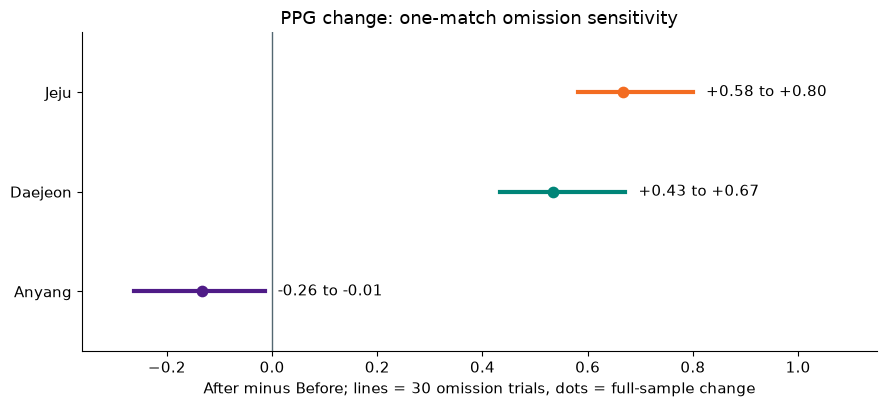

Ranges are not confidence intervals. Venue/opponent reweighting applies to PPG only.


In [6]:
view = robustness.set_index("team").loc[FOCUS_TEAMS]
fig, ax = plt.subplots(figsize=(9, 4.2))
for i, (team, row) in enumerate(view.iterrows()):
    ax.plot([row.loo_min, row.loo_max], [i, i], color=COLORS[team], linewidth=3)
    ax.scatter(row.delta_ppg, i, color=COLORS[team], s=55, zorder=3)
    ax.text(row.loo_max + 0.025, i, f"{row.loo_min:+.2f} to {row.loo_max:+.2f}", va="center")
ax.set_yticks(range(len(view)), view.index)
ax.set_ylim(-0.6, len(view)-0.4)
ax.set_xlim(min(0, view.loo_min.min())-0.1, view.loo_max.max()+0.35)
ax.axvline(0, color="#536771", linewidth=1)
ax.set_title("PPG change: one-match omission sensitivity")
ax.set_xlabel("After minus Before; lines = 30 omission trials, dots = full-sample change")
save_chart(fig, T / "ppg_sensitivity.png")
print("Ranges are not confidence intervals. Venue/opponent reweighting applies to PPG only.")


## Checks and takeaways
The assertions above must pass. Inspect the saved tables and rendered outputs rather than trusting execution alone.

The direction of all three PPG changes survives the displayed reweightings and one-match omission checks. Anyang still conceded about 0.65 more goals per match when R24 is excluded (14 After vs 15 Before).

## Next steps
Remove a different match and explain the changed denominator. Explain why an omission range is not a confidence interval and why PPG checks do not adjust shot metrics.

**Planned:** revisit the analysis after the 2026 season ends, separating the final-round groups and unequal opponent schedules from the current balanced R1-30 comparison.
